In [15]:
import pandas as pd
import numpy as np
housing_df=pd.read_csv('data/housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Ahora lo que hacemos es comprobar que columnas tienen valores nulos, para eso lo hacemos con isnull().sum()

In [12]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

La última columna que es proximidad al océano no es un valor númerico, como vimos anteriormente es un objecto, por lo que comprobamos que valores puede tener

In [13]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Hacemos un gráfico para ver de forma más visual todas las columnas 

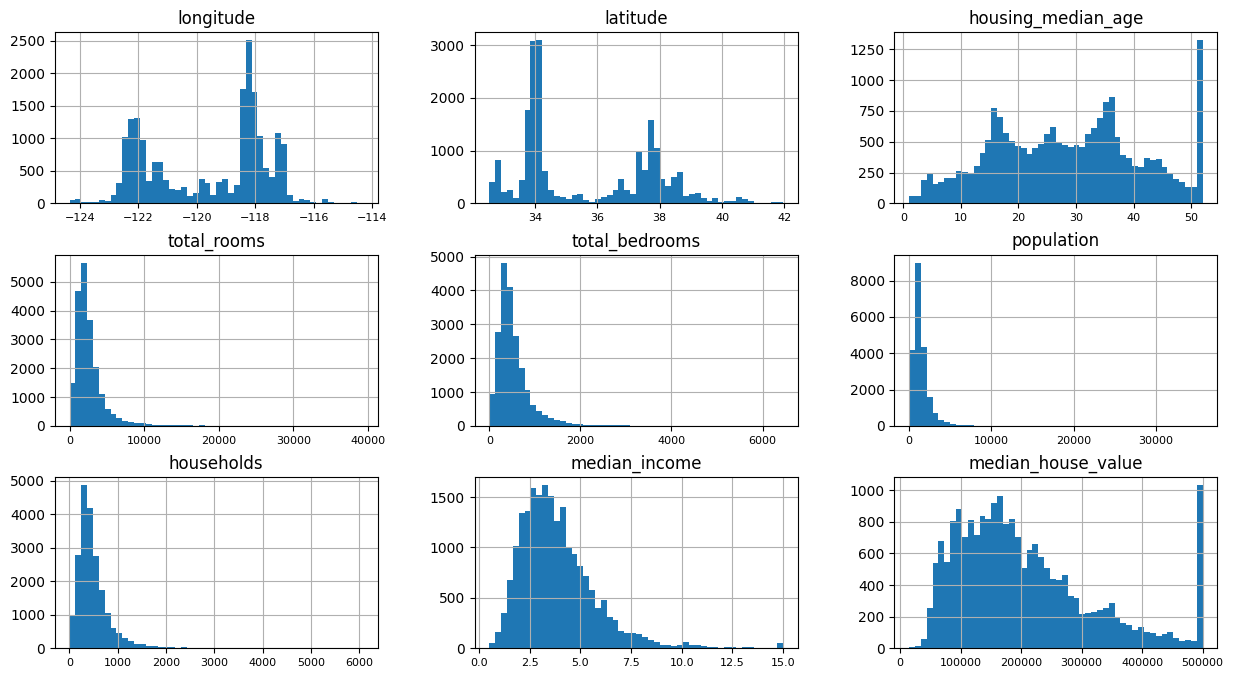

In [14]:
housing_df.hist(bins=50, figsize=(15, 8),
                xlabelsize=8); # Reduce the size of x-axis labels so they don't overlap

En nuestro caso queremos poder deducir la variable del precio, para esto vemos cual de todas las features guarda más relación con nuestra variable.
También tenemos que tener en cuenta que no todo son variables númericas, por lo que primero vamos a extraer las variables numéricas.

In [16]:
corr_matrix = housing_df.corr(numeric_only=True) 

Ahora ya podemos ver que correlación tienen
Lo hacemos con sort_values aplicado a la columna que es nuestra variable y en orden descendente

In [17]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

Ahora es muy importante separar los datos de entrenamiento y de test para poder evitar el overfitting
Nuestros datos de entrenamiento serán el 80% y el resto serán los de test

In [18]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    ''' Shuffles the data and divides it into train (training) and test according to the specified ratio. 
    
        Parameters
        ----------
        data: pandas.DataFrame
            Dataframe containing the data you want to split
        test_ratio: float
            Proportion (between 0 and 1) of data to be used for test (the rest will be used for training)
    
        Returns
        -------
        train_set: pandas.DataFrame
            Dataframe with the training data
        test_set: pandas.DataFrame
            Dataframe with the test data
    '''
    shuffled_indices = np.random.permutation(len(data)) # Generate indices randomly
    test_set_size = int(len(data) * test_ratio) # Calculate the number of samples that will go to the test set
    test_indices = shuffled_indices[:test_set_size] # Select indices for the test set
    train_indices = shuffled_indices[test_set_size:] # Select indices for the training set
    return data.iloc[train_indices], data.iloc[test_indices] # Return the train and test sets

In [19]:
train_set, test_set = shuffle_and_split_data(housing_df, 0.2) # generate train and test sets (20% for test)
len(train_set), len(test_set)

(16512, 4128)

También lo podemos hacer con sklearn

In [21]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_df, test_size=0.2, random_state=42)
len(train_set), len(test_set)

(16512, 4128)

In [28]:
train, test, train_labels, test_labels = train_test_split(
    housing_df.drop(columns="median_house_value"), # Input data (all except the label)
    housing_df["median_house_value"], # Labels
    test_size=0.2,
    random_state=42)
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      3921 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   ocean_proximity     4128 non-null   object 
dtypes: float64(8), object(1)
memory usage: 322.5+ KB


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("./data/housing.csv") 
train_set, test_set = train_test_split(housing, test_size=0.2,
    stratify=pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]),
    random_state=42
    )

In [35]:
X_train = train_set.drop("median_house_value", axis=1) # Remove the dependent variable column
y_train = train_set["median_house_value"].copy() # Save the dependent variable (labels)

X_train.head().T

,12655,15502,2908,14053,20496
longitude,-121.46,-117.23,-119.04,-117.13,-118.7
latitude,38.52,33.09,35.37,32.75,34.28
housing_median_age,29.0,7.0,44.0,24.0,27.0
total_rooms,3873.0,5320.0,1618.0,1877.0,3536.0
total_bedrooms,797.0,855.0,310.0,519.0,646.0
population,2237.0,2015.0,667.0,898.0,1837.0
households,706.0,768.0,300.0,483.0,580.0
median_income,2.1736,6.3373,2.875,2.2264,4.4964
ocean_proximity,INLAND,NEAR OCEAN,INLAND,NEAR OCEAN,<1H OCEAN


Volvemos a comprobar las columnas que tienen valores nulos

In [36]:
X_train.isna().sum() # the isnull() method is an alias for isna()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [37]:
null_rows_idx = X_train.isnull().any(axis=1) # indices of rows with null values
X_train.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN


Los valores nulos nos pueden traer problemas, por lo que eliminaremos todas las filas que tengan cualquier valor nulo en una de sus columnas
Esto supondrá menos datos en nuestra base de datos, pero de esta forma nos aseguramos que todos sean datos reales.

In [38]:
X_train_ld_any = X_train.dropna(axis=0) # remove rows with null values
X_train_ld_any.loc[null_rows_idx].head() # verify that rows with null values have been removed

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [40]:
X_train_ld_any.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


Hay que tener clara la diferencia entre mean y median:
Mean: es la suma de todos los valores y dividida por el total, de manera que es sensible a los valores extremos
Median: una vez ordenados los datos la mediano es el punto medio, el 50%, de esta forma es robusta a datos atípicos.

Como la columna "total_bedrooms" es un parámetro importante para el cálculo de "bedrroms_ratio" ya que depende de ella, no podemos eliminar esta columna

In [42]:
train_set["rooms_per_house"] = train_set["total_rooms"] / train_set["households"] # number of rooms per house
train_set["bedrooms_ratio"] = train_set["total_bedrooms"] / train_set["total_rooms"] # ratio of bedrooms to total rooms
train_set["people_per_house"] = train_set["population"] / train_set["households"] # number of people per house

Lo que haremos será crear una varaible que almacene el valor de la mediana de esta columna para posteriormente rellenar todos los datos que no sean válidos con este valor

In [43]:
median = X_train["total_bedrooms"].median()
housing_option3 = X_train["total_bedrooms"].fillna(median)
housing_option3.loc[null_rows_idx].head()

1606     433.0
10915    433.0
19150    433.0
4186     433.0
16885    433.0
Name: total_bedrooms, dtype: float64

Hay una forma más fácil de hacer este proceso, es con sklearn.impute:

In [44]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = X_train.select_dtypes(include=[np.number]) # select numerical columns
imputer.fit(housing_num) # calculate the median of each numerical column
imputer.statistics_ # median of each numerical column
housing_num.median().values
housing_num_array_tr = imputer.transform(housing_num) # replace null values with the median
housing_num_array_tr

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]], shape=(16512, 8))

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("./data/housing.csv")
train_set, test_set = train_test_split(housing, test_size=0.2,
    stratify=pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]),
    random_state=42
    )

X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"].copy()
X_train_num = X_train.select_dtypes(include=[np.number])

Otra parte muy importante es el escalado, sklearn incorpora una función para esto.
Con esta función MinMax extraemos escalamos todo a los valores mínimos y máximos, pero hay que tener cuidado con los outliers, tienen que ser datos reales y no errores, ya que, en el caso de tener todos los datos entre 20 y 30 pero solamente uno es 100, todos se van a escalar con este último valor como máximo.

In [47]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(X_train_num)

También hay otro tipo de función para otra escala, que es la estándar, esta coge el valor de la mediana y la divide entre la desviación estándar.
Este es menos sensitivo a los outliers ya que no establece máximo o mínimos.

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(X_train_num)